In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import json
import itertools

In [2]:
DATA_ROOT = "/root/yb-soc-two-body-loss/data/fig3b_T2_gamma_0929"

In [3]:
def query_condition(name):
    return True

for name in os.listdir(DATA_ROOT):
    if query_condition(name):
        print(name)

sim_0_009290733
sim_0_109290812
sim_0_209290850
sim_1_009290929
sim_1_109291007
sim_1_209291046
sim_2_009291124
sim_2_109291203
sim_2_209291241
sim_3_009291320
sim_3_109291359
sim_3_209291437


In [ ]:
DATA_SUBDIR_LIST = [
    "sim_0_009290733",
    "sim_0_109290812",
    "sim_0_209290850",
    "sim_1_009290929",
    "sim_1_109291007",
    "sim_1_209291046",
    "sim_2_009291124",
    "sim_2_109291203",
    "sim_2_209291241",
    "sim_3_009291320",
    "sim_3_109291359",
    "sim_3_209291437",
]
DATA_SUBDIR_FULL = [
    os.path.join(DATA_ROOT, name) for name in DATA_SUBDIR_LIST
]

In [5]:
def load_params(data_dir):
    data_path = os.path.join(data_dir, "data/parameters.json")
    with open(data_path, 'r') as f:
        params = json.load(f)
    return params

def load_nparray(data_dir, file_name):
    data_path = os.path.join(data_dir, "data", file_name)
    with open(data_path, 'rb') as f:
        nparr = np.load(f)
    return nparr

def load_times(data_dir):
    return load_nparray(data_dir, "t.npy")

def load_full_momentum_nums(data_dir):
    up_nums = load_nparray(data_dir, "full_up_nums_momentum.npy")
    down_nums = load_nparray(data_dir, "full_down_nums_momentum.npy")
    return up_nums, down_nums

def load_nh_state_norm_square(data_dir):
    state_norm_sq = load_nparray(data_dir, "state_norm_square_nh.npy")
    return state_norm_sq

In [6]:
err = 0
params = []
for idx, data_dir in enumerate(DATA_SUBDIR_FULL):
    params.append(load_params(data_dir))

In [7]:
def merge_params(params_list):
    if not params_list:
        return {}, []

    merged_keys = set()

    def _recursive_merge(current_params_list, path_prefix=""):
        if not current_params_list:
            return {}

        all_keys = set().union(*(d.keys() for d in current_params_list))
        merged_dict = {}

        for key in all_keys:
            values = [d.get(key) for d in current_params_list if key in d]
            
            unique_values = []
            for v in values:
                if v not in unique_values:
                    unique_values.append(v)
            
            full_key_path = f"{path_prefix}{key}"

            if len(unique_values) == 1:
                merged_dict[key] = unique_values[0]
            else:
                if all(isinstance(v, dict) for v in unique_values):
                    merged_dict[key] = _recursive_merge(unique_values, path_prefix=f"{full_key_path}.")
                else:
                    merged_keys.add(full_key_path)
                    merged_dict[key] = unique_values
        
        return merged_dict

    final_merged_dict = _recursive_merge(params_list)

    return final_merged_dict, sorted(list(merged_keys))

In [8]:
merged_params, merged = merge_params(params)
# print(merged)
# pointer = merged_params
# for key in merged[0].split('.'):
#     pointer = pointer[key]
# print(f"{key}: {pointer}")
print(json.dumps(merged_params, indent=4))

{
    "n_momentum_points": 13,
    "L": 12.566370614359172,
    "soc": {
        "k_r": 1.0,
        "delta": 4.0,
        "omega_R": 3.5
    },
    "simulation_settings": {
        "t0": 0,
        "t1": 3.0,
        "mode": "non-Hermitian",
        "zerotemp": true,
        "temperature": 0.0,
        "n_savesteps": 76,
        "step_size": 0.354295837023915,
        "n_trajectories": 512,
        "batch_size": 64,
        "jumps_per_step": 4,
        "num_batches": 8,
        "total_n_steps": 300,
        "delta_t": 0.08857395925597875,
        "seed": 0
    },
    "hbar": 1.0,
    "pa": {
        "gamma": [
            0.18,
            0.32,
            1.0
        ],
        "T2": [
            0.4,
            0.8,
            2.0,
            1000000.0
        ]
    },
    "n_particles": 6,
    "k0": 0.5,
    "m_Yb": 1.0
}


In [9]:
err = 0
for idx, data_dir in enumerate(DATA_SUBDIR_FULL):
    ts = load_times(data_dir)
    if idx == 0:
        ts_ref = ts
    else:
        err += np.mean(np.abs(ts - ts_ref))
print('error:', err)

error: 0.0


In [10]:
# System definition
t_r = 0.1129 # ms
E_r = 9.3428e-31 # J
T_r = 6.7669e-2 # μK

In [11]:
exp_data_path_root = "/root/yb-soc-two-body-loss/data/experiment/OneDrive_1_7-5-2025/"

In [12]:
exp_data_path_fig_a = os.path.join(exp_data_path_root, "unit_figure_3_a.csv")
exp_data_path_fig_b = os.path.join(exp_data_path_root, "unit_figure_3_b.csv")

In [13]:
import pandas as pd
df_fig3a = pd.read_csv(exp_data_path_fig_a)
time_exp_a = np.array(df_fig3a["time"]) * 1000 # s -> ms
nums_exp_a = np.array(df_fig3a["mean"])
errors_exp_a = np.array(df_fig3a["se"])

df_fig3b = pd.read_csv(exp_data_path_fig_b)
time_exp_b = np.array(df_fig3b["time"]) * 1000 # s -> ms
nums_exp_b = np.array(df_fig3b["mean"])
errors_exp_b = np.array(df_fig3b["se"])

In [14]:
DATA_SUBDIR_FULL

['/root/yb-soc-two-body-loss/data/fig3a_T2_gamma_0929/sim_0_009281941',
 '/root/yb-soc-two-body-loss/data/fig3a_T2_gamma_0929/sim_0_109282036',
 '/root/yb-soc-two-body-loss/data/fig3a_T2_gamma_0929/sim_0_209282130',
 '/root/yb-soc-two-body-loss/data/fig3a_T2_gamma_0929/sim_1_009282224',
 '/root/yb-soc-two-body-loss/data/fig3a_T2_gamma_0929/sim_1_109282318',
 '/root/yb-soc-two-body-loss/data/fig3a_T2_gamma_0929/sim_1_209290012',
 '/root/yb-soc-two-body-loss/data/fig3a_T2_gamma_0929/sim_2_009290106',
 '/root/yb-soc-two-body-loss/data/fig3a_T2_gamma_0929/sim_2_109290159',
 '/root/yb-soc-two-body-loss/data/fig3a_T2_gamma_0929/sim_2_209290253',
 '/root/yb-soc-two-body-loss/data/fig3a_T2_gamma_0929/sim_3_009290347',
 '/root/yb-soc-two-body-loss/data/fig3a_T2_gamma_0929/sim_3_109290441',
 '/root/yb-soc-two-body-loss/data/fig3a_T2_gamma_0929/sim_3_209290535']

In [17]:
T2s = merged_params["pa"]["T2"]
gammas = merged_params["pa"]["gamma"]

In [19]:
for idx_T2, idx_gamma in itertools.product(range(len(T2s)), range(len(gammas))):
    print(f"T2: {idx_T2}, gamma: {idx_gamma}")

T2: 0, gamma: 0
T2: 0, gamma: 1
T2: 0, gamma: 2
T2: 1, gamma: 0
T2: 1, gamma: 1
T2: 1, gamma: 2
T2: 2, gamma: 0
T2: 2, gamma: 1
T2: 2, gamma: 2
T2: 3, gamma: 0
T2: 3, gamma: 1
T2: 3, gamma: 2


In [21]:
DATA_DIRS = {
    (idx_T2, idx_gamma): data_dir
    for (idx_T2, idx_gamma), data_dir
    in zip(itertools.product(range(len(T2s)), range(len(gammas))), DATA_SUBDIR_FULL)
}

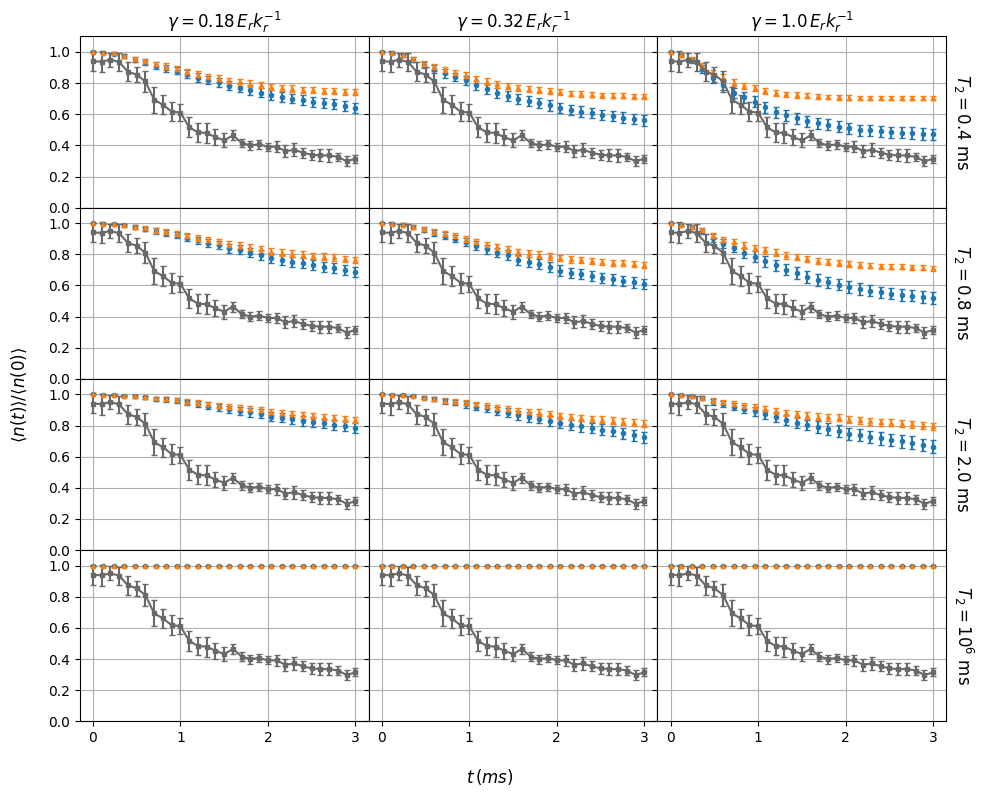

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import itertools

# --- 가정: 이전 코드와 동일하게 필요한 변수와 함수가 모두 정의되어 있다고 가정합니다 ---
# T2s, gammas, DATA_DIRS, load_params, 등등
# --------------------------------------------------------------------------

# 1. 서브플롯 생성 시 gridspec_kw를 추가하여 간격을 없앱니다.
#    figsize는 그림 크기이므로 적절히 조절하세요.
fig, axs = plt.subplots(4, 3, 
                        figsize=(10, 8), 
                        sharex='col', 
                        sharey='row',
                        gridspec_kw={'wspace': 0, 'hspace': 0})

# 메인 루프
for idx_T2, idx_gamma in itertools.product(range(len(T2s)), range(len(gammas))):
    # --- 데이터 로딩 및 계산 (기존과 동일) ---
    data_dir = DATA_DIRS[(idx_T2, idx_gamma)]
    params = load_params(data_dir)
    save_at = load_times(data_dir)
    ts = save_at * t_r
    n_particles = params['n_particles']
    T2 = params["pa"]['T2']
    gamma = params["pa"]['gamma']
    # ... (나머지 계산 코드는 생략) ...
    nums_up, nums_down = load_full_momentum_nums(data_dir)
    norm_sq_nh = load_nh_state_norm_square(data_dir)
    n_traj = nums_up.shape[0]
    nums_up /= n_particles
    nums_down /= n_particles
    total_nums = np.sum(nums_up, axis=2) + np.sum(nums_down, axis=2)
    nums = np.mean(total_nums, axis=0)
    stds = np.std(total_nums, axis=0)
    errors = 3 * stds / np.sqrt(n_traj)
    temp = (2 * norm_sq_nh + (n_particles - 2)) / n_particles
    nums_nh = np.mean(temp, axis=0)
    stds_nh = np.std(temp, axis=0)
    errors_nh = 3 * stds_nh / np.sqrt(n_traj)
    # --- 계산 끝 ---

    ax = axs[idx_T2, idx_gamma]
    
    # 2. 개별 서브플롯의 title 설정을 제거합니다.
    # ax.set_title(...)  <-- 이 줄을 삭제 또는 주석 처리

    # 에러바 플롯팅
    ax.errorbar(ts[::3], nums[::3], yerr=errors[::3], fmt='o', markersize=3, capsize=2, color='tab:blue', label='Lindbladian (num)')
    ax.errorbar(ts[::3], nums_nh[::3], yerr=errors_nh[::3], fmt='^', markersize=3, capsize=2, color='tab:orange', label='Non-Hermitian (num)')
    ax.errorbar(time_exp_a, nums_exp_a, yerr=errors_exp_a, fmt='s-', markersize=3, capsize=2, color='dimgrey', label='(exp)')

    ax.grid()
    ax.set_ylim(0.0, 1.1)

# --- 루프 종료 후 라벨링 및 레이아웃 조정 ---

# 3. 맨 위 행에 gamma 값을 "열 제목"으로 추가합니다.
for idx_gamma, gamma in enumerate(gammas):
    axs[0, idx_gamma].set_title(f"$\\gamma = {gamma}\\, E_r k_r^{{-1}}$")

# 4. 맨 오른쪽 열에 T2 값을 "행 라벨"로 추가합니다.
for idx_T2, T2 in enumerate(T2s):
    ax_right = axs[idx_T2, -1] # 각 행의 가장 오른쪽 subplot
    ax_right.yaxis.set_label_position("right") # 라벨 위치를 오른쪽으로
    if idx_T2 == 3:
        ax_right.set_ylabel(f"$T_2 = 10^6$ ms", rotation=-90, va='bottom', fontsize=12) # 라벨 설정
    else:
        ax_right.set_ylabel(f"$T_2 = {T2}$ ms", rotation=-90, va='bottom', fontsize=12) # 라벨 설정

# 전체 그림의 공통 X, Y 축 라벨 설정 (기존과 동일)
fig.supxlabel("$t\\,(ms)$")
fig.supylabel("$\\langle n(t)\\rangle/\\langle n(0)\\rangle$")

# 레이아웃을 꽉 차게 조절하고 그림을 표시합니다.
plt.tight_layout()
# tight_layout 후에 subplot 간격을 다시 한번 명시적으로 조절할 수 있습니다.
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

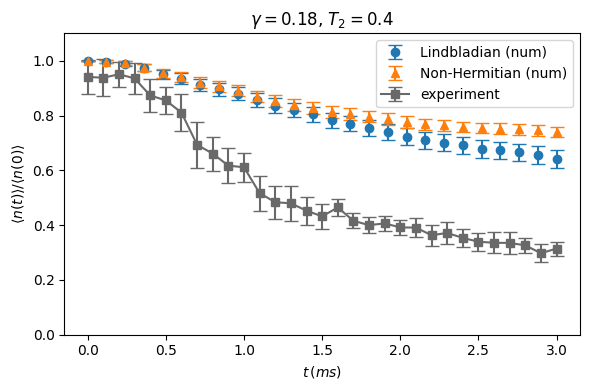

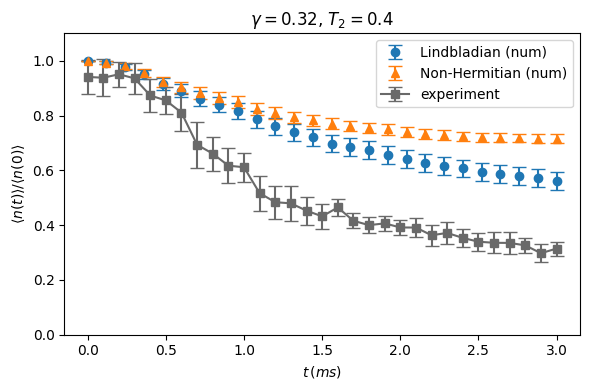

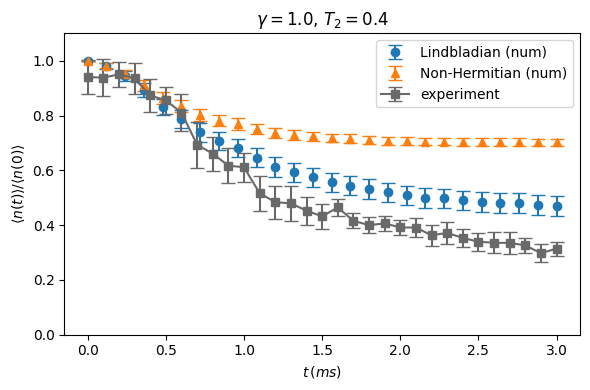

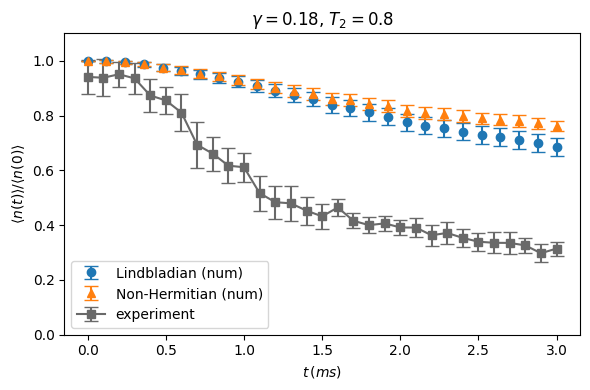

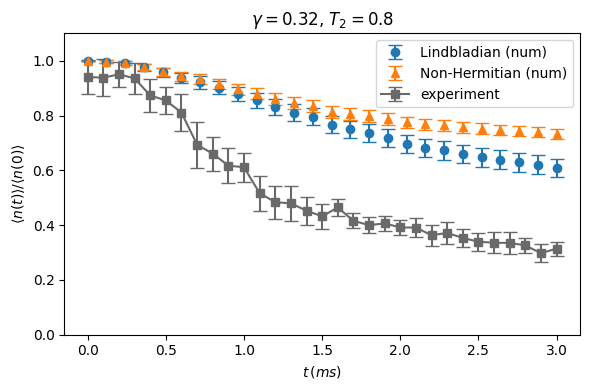

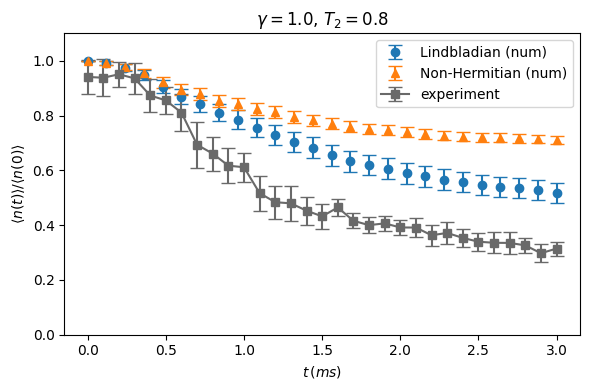

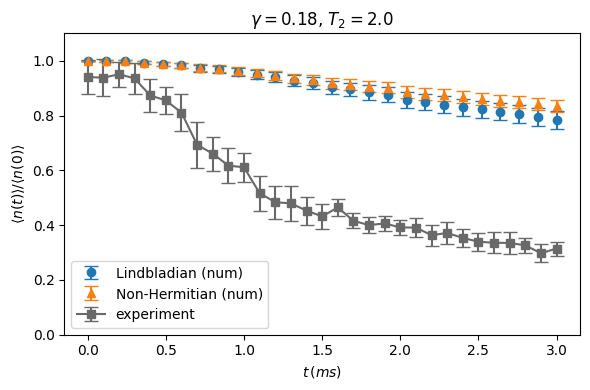

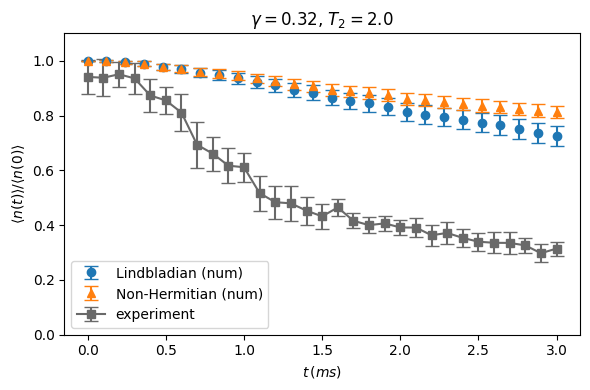

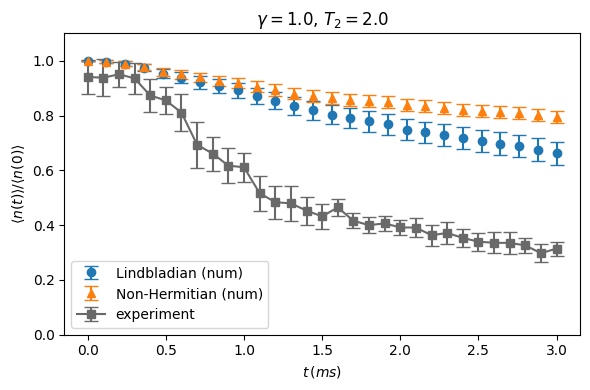

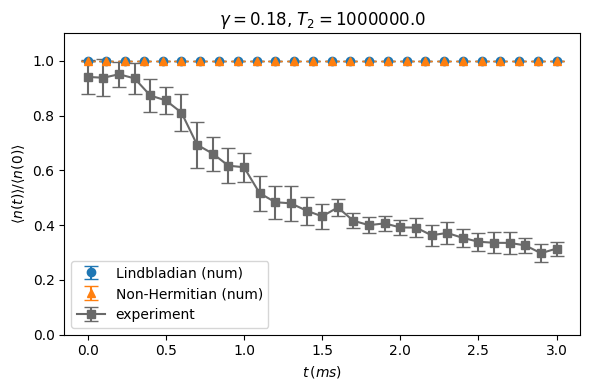

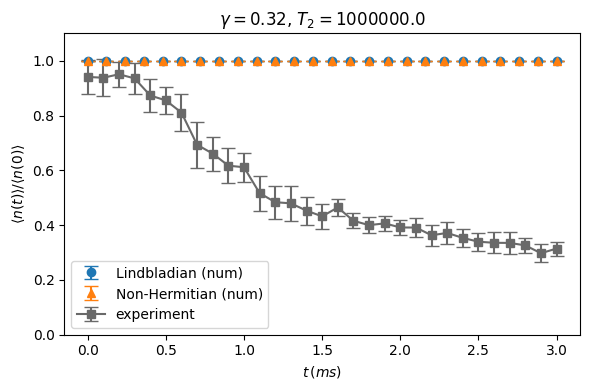

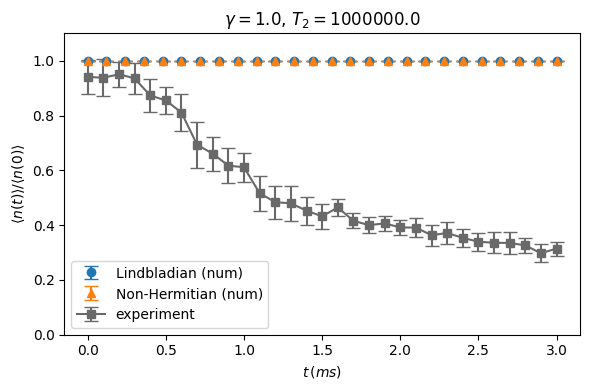

In [46]:
# idx_T2 : 0, 1, 2, 3
# idx_gamma : 0, 1, 2
for idx_T2, idx_gamma in itertools.product(range(len(T2s)), range(len(gammas))):
    data_dir = DATA_DIRS[(idx_T2, idx_gamma)]
    params = load_params(data_dir)
    save_at = load_times(data_dir)
    ts = save_at * t_r
    
    n_particles = params['n_particles']
    T2 = params["pa"]['T2'] # ms
    gamma = params["pa"]['gamma'] 
    assert T2 == T2s[idx_T2]
    assert gamma == gammas[idx_gamma]
    
    nums_up, nums_down = load_full_momentum_nums(data_dir)
    norm_sq_nh = load_nh_state_norm_square(data_dir)
    assert nums_up.shape == nums_down.shape
    n_traj = nums_up.shape[0]
    
    nums_up /= n_particles
    nums_down /= n_particles
    
    total_nums = np.sum(nums_up, axis=2) + np.sum(nums_down, axis=2)
    nums = np.mean(total_nums, axis=0)
    stds = np.std(total_nums, axis=0)
    errors = 3 * stds / np.sqrt(n_traj)
    
    temp = (2 * norm_sq_nh + (n_particles - 2)) / n_particles
    nums_nh = np.mean(temp, axis=0)
    stds_nh = np.std(temp, axis=0)
    errors_nh = 3 * stds_nh / np.sqrt(n_traj)
    
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    ax.set_title(f"$\\gamma = {gamma}$, $T_2 = {T2}$")
    ax.errorbar(ts[::3], nums[::3], yerr=errors[::3], fmt='o', capsize=5, color='tab:blue', label='Lindbladian (num)')
    ax.errorbar(ts[::3], nums_nh[::3], yerr=errors_nh[::3], fmt='^', capsize=5, color='tab:orange', label='Non-Hermitian (num)')
    ax.errorbar(time_exp_a, nums_exp_a, yerr=errors_exp_a, fmt='s-', capsize=5, color='dimgrey', label='experiment')
    ax.legend()
    ax.set_ylim(0.0, 1.1)
    ax.set_xlabel("$t\\,(ms)$")
    ax.set_ylabel("$\\langle n(t)\\rangle/\\langle n(0)\\rangle$")
    
    plt.tight_layout()
    plt.show()

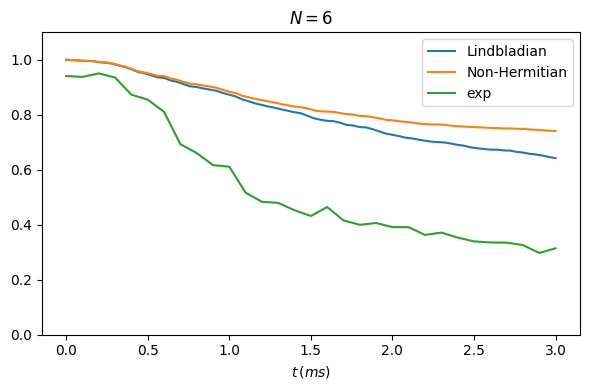

In [26]:
data_dir = DATA_SUBDIR_FULL[0]
params = load_params(data_dir)
n = params['n_particles']
state_norm_square_nh = load_nh_state_norm_square(data_dir)
total_nums_nh = 2 * np.mean(state_norm_square_nh, axis=0) + (n - 2)

nums_up, nums_down = load_full_momentum_nums(data_dir)
nums_up_avg = np.mean(nums_up, axis=0)
nums_down_avg = np.mean(nums_down, axis=0)
total_nums_lindblad = np.sum(nums_up_avg, axis=-1) + np.sum(nums_down_avg, axis=-1)

save_at = load_times(data_dir)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ts = save_at * t_r
ax.set_title(f"$N={n}$")
ax.plot(ts, total_nums_lindblad / n, label='Lindbladian')
ax.plot(ts, total_nums_nh / n, label='Non-Hermitian')
ax.plot(time_exp_a, nums_exp_a, label='exp')
ax.legend()
ax.set_ylim(0.0, 1.1)
ax.set_xlabel("$t\\,(ms)$")

plt.tight_layout()
plt.show()

In [27]:
ts = ts_ref
ts_ms = ts_ref * t_r
print(f"{len(ts)=}")
print(ts_ms)

len(ts)=76
[0.   0.04 0.08 0.12 0.16 0.2  0.24 0.28 0.32 0.36 0.4  0.44 0.48 0.52
 0.56 0.6  0.64 0.68 0.72 0.76 0.8  0.84 0.88 0.92 0.96 1.   1.04 1.08
 1.12 1.16 1.2  1.24 1.28 1.32 1.36 1.4  1.44 1.48 1.52 1.56 1.6  1.64
 1.68 1.72 1.76 1.8  1.84 1.88 1.92 1.96 2.   2.04 2.08 2.12 2.16 2.2
 2.24 2.28 2.32 2.36 2.4  2.44 2.48 2.52 2.56 2.6  2.64 2.68 2.72 2.76
 2.8  2.84 2.88 2.92 2.96 3.  ]


In [ ]:
n_particles = merged_params['n_particles']

In [ ]:
n_particles

[2, 3, 4, 5, 6]

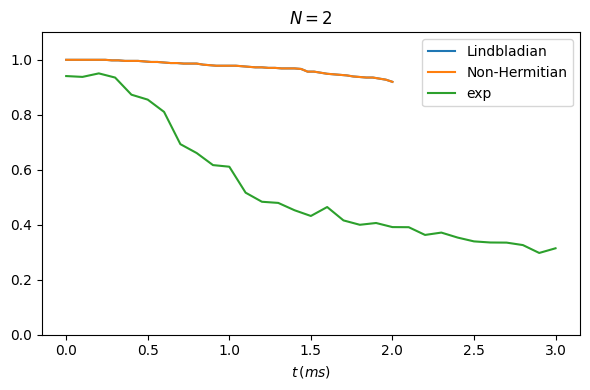

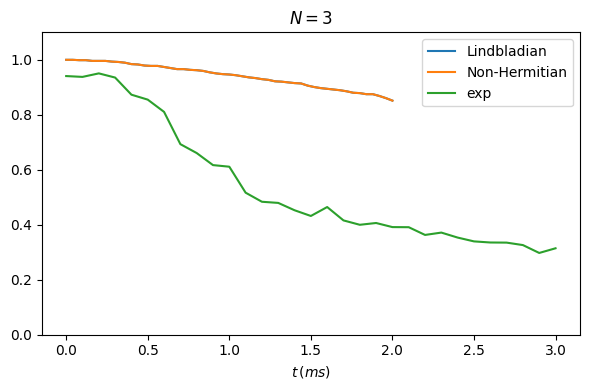

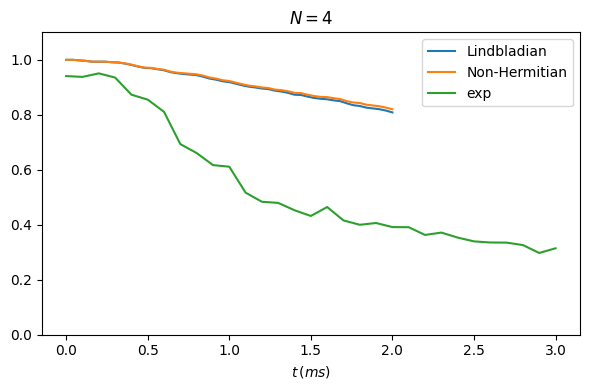

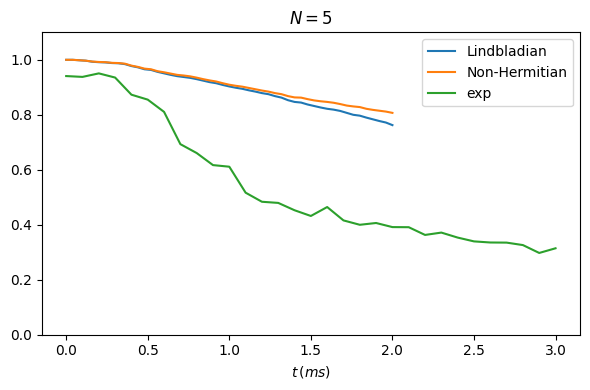

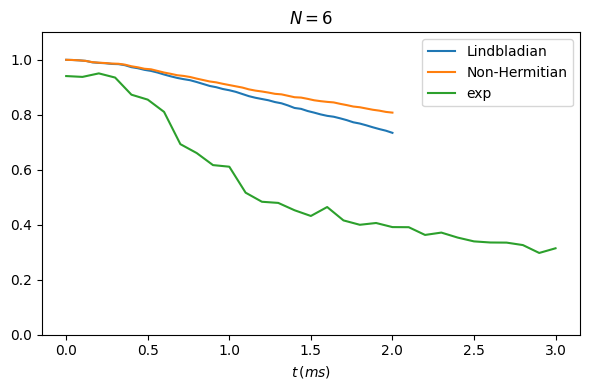

In [ ]:
from quant_mech.plot_utils import (
    plot_numbers,
    generate_k_labels,
    plot_fractions
)

for n, data_dir in zip(n_particles, DATA_SUBDIR_FULL):
    # (batch, time, k)
    params = load_params(data_dir)
    state_norm_square_nh = load_nh_state_norm_square(data_dir)
    total_nums_nh = 2 * np.mean(state_norm_square_nh, axis=0) + (n - 2)
    
    nums_up, nums_down = load_full_momentum_nums(data_dir)
    nums_up_avg = np.mean(nums_up, axis=0)
    nums_down_avg = np.mean(nums_down, axis=0)
    total_nums_lindblad = np.sum(nums_up_avg, axis=-1) + np.sum(nums_down_avg, axis=-1)
    
    save_at = load_times(data_dir)

    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    ts = save_at * t_r
    ax.set_title(f"$N={n}$")
    ax.plot(ts, total_nums_lindblad / n, label='Lindbladian')
    ax.plot(ts, total_nums_nh / n, label='Non-Hermitian')
    ax.plot(exp_time, exp_nums, label='exp')
    ax.legend()
    ax.set_ylim(0.0, 1.1)
    ax.set_xlabel("$t\\,(ms)$")

    plt.tight_layout()
    plt.show()